Goal: train NeuralODE with fixed interval on test images with fixed variance gaussian noise.

In [1]:
using Pkg
Pkg.activate("../../")
Pkg.instantiate()

  Activating project at `~/Code/Julia/ImplicitDenoiser`


In [2]:
im_path = "../../../Images/128/"

"../../../Images/128/"

In [3]:
using Lux, LuxCUDA, MLUtils
using Optimisers, Random, Statistics
using Zygote
using DiffEqFlux, OrdinaryDiffEq
using FFTW
#using Reactant
using Images, JLD2
using ComponentArrays
using DeepEquilibriumNetworks
using Plots
using Dates

In [4]:
#Reactant.set_default_backend("cpu")
#const device = reactant_device()
const cdev = cpu_device()
const gdev = gpu_device()
dev = gdev

(::CUDADevice{Nothing, Missing}) (generic function with 1 method)

In [21]:
include("model.jl")

NeuralODE(
    model = Chain(
        layer_1 = Chain(
            layer_1 = Conv((5, 5), 1 => 8, gelu_tanh, pad=2),  # 208 parameters
            layer_2 = Conv((5, 5), 8 => 16, gelu_tanh, pad=2),  # 3_216 parameters
            layer_3 = SkipConnection(
                connection = +,
                layers = Chain(
                    layer_1 = Conv((1, 1), 16 => 64, tanh),  # 1_088 parameters
                    layer_2 = Conv((1, 1), 64 => 32, tanh),  # 2_080 parameters
                    layer_3 = Conv((1, 1), 32 => 16),  # 528 parameters
                ),
            ),
        ),
        layer_2 = Conv((5, 5), 16 => 32, gelu_tanh, pad=2),  # 12_832 parameters
        layer_3 = Conv((5, 5), 32 => 64, gelu_tanh, pad=2),  # 51_264 parameters
        layer_4 = SkipConnection(
            connection = +,
            layers = Chain(
                layer_1 = Conv((1, 1), 64 => 128, gelu_tanh),  # 8_320 parameters
                layer_2 = Conv((1, 1), 128 => 128, gelu_tanh),  # 16_

In [8]:
rng = Xoshiro(0)
ps, st = Lux.setup(rng, model)

((layer_1 = (layer_1 = (weight = Float32[-0.30580238 0.18938486 … 0.33024654 0.12650087; -0.031011743 -0.26833618 … 0.25797793 -0.2773095; … ; 0.03300763 -0.06136041 … 0.07961983 -0.18696542; 0.12824844 -0.32586965 … 0.11916554 0.18865287;;;; 0.09093706 3.0558529f-6 … -0.19399974 0.021667441; -0.111984864 -0.020606318 … 0.12386206 0.15174432; … ; 0.21957335 -0.2668298 … 0.23292983 0.06296065; 0.13718541 -0.026979052 … 0.04520965 -0.05915359;;;; 0.25620753 0.0105199795 … -0.06364512 -0.14203967; -0.07936133 -0.21008675 … -0.036428407 -0.32864538; … ; -0.18309778 0.22447027 … -0.2649486 0.30478093; 0.30851713 0.10652034 … -0.2563771 0.08460723;;;; 0.06988987 -0.12302083 … 0.1797195 -0.084307514; -0.13215667 -0.06367559 … -0.1801825 -0.32524836; … ; -0.21732795 0.16682376 … 0.18481661 0.22907941; -0.16016795 0.1763368 … 0.31328383 -0.27067426;;;; -0.12116444 0.28295907 … 0.15405698 -0.001604777; 0.22731717 0.089358136 … 0.21253197 0.016441934; … ; -0.2766099 -0.13225459 … 0.22571252 0.344

In [6]:
@load "st0.0059276796_2026-01-08T00:48:32.420.jld2" st
@load "ps0.0059276796_2026-01-08T00:48:32.420.jld2" ps

1-element Vector{Symbol}:
 :ps

In [7]:
ps = ps |> ComponentArray |> dev
st = st |> dev

(layer_1 = (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple())), layer_2 = NamedTuple(), layer_3 = NamedTuple(), layer_4 = (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()), layer_5 = NamedTuple(), layer_6 = NamedTuple())

In [8]:
opt = Optimisers.NAdam(1e-3)
state = Optimisers.setup(opt,ps)
train_state = Lux.Training.TrainState(model, ps, st, opt)

TrainState(
    NeuralODE(
        model = Chain(
            layer_1 = Chain(
                layer_1 = Conv((5, 5), 1 => 8, gelu_tanh, pad=2),  # 208 parameters
                layer_2 = Conv((5, 5), 8 => 16, gelu_tanh, pad=2),  # 3_216 parameters
                layer_3 = SkipConnection(
                    connection = +,
                    layers = Chain(
                        layer_1 = Conv((1, 1), 16 => 64, tanh),  # 1_088 parameters
                        layer_2 = Conv((1, 1), 64 => 32, tanh),  # 2_080 parameters
                        layer_3 = Conv((1, 1), 32 => 16),  # 528 parameters
                    ),
                ),
            ),
            layer_2 = Conv((5, 5), 16 => 32, gelu_tanh, pad=2),  # 12_832 parameters
            layer_3 = Conv((5, 5), 32 => 64, gelu_tanh, pad=2),  # 51_264 parameters
            layer_4 = SkipConnection(
                connection = +,
                layers = Chain(
                    layer_1 = Conv((1, 1), 64 => 128, gelu_tanh

In [12]:
function loss_function(model, ps, st, (x, y_true))
    y_pred = model(x, ps, st)[1][1]
    loss_mse= MSELoss()
    mse_loss = loss_mse(y_pred, y_true)
    #sptrl_loss = loss_mse(dct(dct(y_pred,1),2),dct(dct(y_pred,1),2))
    return mse_loss, st
    #return mes_loss + sptrl_loss, st
end

loss_function (generic function with 1 method)

In [13]:
# This is to test the model if it works:
x = randn(Float32,128,128,1,4)
y_true = randn(Float32,128,128,1,4)
x_dev = x |> dev
y_dev = y_true |> dev
y, _ = model(x_dev, ps, st)

(ODESolution{Float32, 5, Vector{CuArray{Float32, 4, CUDA.DeviceMemory}}, Nothing, Nothing, Vector{Float32}, Vector{Vector{CuArray{Float32, 4, CUDA.DeviceMemory}}}, Nothing, ODEProblem{CuArray{Float32, 4, CUDA.DeviceMemory}, Tuple{Float32, Float32}, false, ComponentVector{Float32, CuArray{Float32, 1, CUDA.DeviceMemory}, Tuple{ComponentArrays.Axis{(layer_1 = ViewAxis(1:7120, Axis(layer_1 = ViewAxis(1:208, Axis(weight = ViewAxis(1:200, ShapedAxis((5, 5, 1, 8))), bias = ViewAxis(201:208, Shaped1DAxis((8,))))), layer_2 = ViewAxis(209:3424, Axis(weight = ViewAxis(1:3200, ShapedAxis((5, 5, 8, 16))), bias = ViewAxis(3201:3216, Shaped1DAxis((16,))))), layer_3 = ViewAxis(3425:7120, Axis(layer_1 = ViewAxis(1:1088, Axis(weight = ViewAxis(1:1024, ShapedAxis((1, 1, 16, 64))), bias = ViewAxis(1025:1088, Shaped1DAxis((64,))))), layer_2 = ViewAxis(1089:3168, Axis(weight = ViewAxis(1:2048, ShapedAxis((1, 1, 64, 32))), bias = ViewAxis(2049:2080, Shaped1DAxis((32,))))), layer_3 = ViewAxis(3169:3696, Axis(

In [14]:
#=loss_function(model,ps,st,(x_dev,y_dev))
(loss, st), back = Zygote.pullback(ps -> loss_function(model, ps, st, (x_dev, y_dev)), ps)
grads = back((one(loss), nothing))[1]
state, ps = Optimisers.update(state, ps, grads)
train_state = Lux.Training.TrainState(model, ps, st, opt)

println("Loss: ", loss)
=#

In [12]:
function add_gaussian_noise(img, σ = 1e-3 )
    out = img .+ σ .* randn(eltype(img), size(img))
    if rand(Bool)
        @. out = min(max(out, 0.0),1.0) 
    end
    out
end

add_gaussian_noise (generic function with 2 methods)

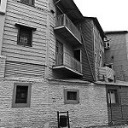

In [16]:
img = load(im_path * "1.jpg")

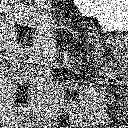

In [17]:
Gray.(add_gaussian_noise(Float32.(img), 4e-1))

In [18]:
function load_images_to_array(path,num,corrupt_func)
    x = zeros(Float32,128,128,1,num)
    y = zeros(Float32,128,128,1,num)
    for i in 1:num
        img = Float32.(load("$path$i.jpg"))
        #x[:,:,1,i] = Float32.(outdict["array"])
        #y[:,:,1,i] = Float32.(outdict["original"])
        x[:,:,1,i] = corrupt_func(img)
        y[:,:,1,i] = img
    end
    return x,y
end

load_images_to_array (generic function with 1 method)

In [13]:
cfunc(img) = add_gaussian_noise(Float32.(img),2e-1)

cfunc (generic function with 1 method)

In [20]:
X, Y = load_images_to_array(im_path,7000, cfunc)

(Float32[0.23056369 0.88238895 … 0.96546865 1.3387389; 0.06351939 0.7786475 … 0.8735926 0.6518164; … ; 0.16824435 0.3953002 … 0.63909996 0.71740675; 0.5023168 0.77193147 … 0.5086251 0.44424516;;;; 0.33411884 0.45607126 … 0.066087954 0.2936949; 0.5204166 0.13421793 … 0.70318496 0.5808512; … ; 0.33969092 0.14242442 … 0.15385415 0.5156344; 0.018164065 0.3831791 … 0.10511362 0.055931542;;;; -0.12839007 0.10434503 … 0.3245981 -0.046808414; -0.001202216 0.69877005 … 0.086577944 0.01196789; … ; 0.36831036 0.23756388 … 0.5773861 -0.011642128; 0.40770644 0.45561373 … 0.21115682 0.18085805;;;; … ;;;; 0.29790464 -0.003958544 … 0.057096295 0.317295; 0.38099775 0.45544937 … 0.12603444 -0.20255072; … ; 0.21516062 0.1520331 … 0.58849233 0.864002; -0.0072625964 -0.106500015 … 0.7183215 0.51632094;;;; 0.18383746 0.22761816 … 0.198819 -0.098724246; -0.25616503 0.2080548 … 0.7245256 0.05476007; … ; 0.21186201 0.08607349 … -0.07925395 0.15162201; -0.1347898 -0.0695774 … 0.27925742 -0.016586676;;;; 0.35376

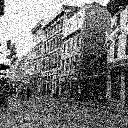

In [21]:
Gray.(X[:,:,1,3])

In [20]:
function load_images(batchsize, path, num, corrupt_func)
    x_img,y_img = load_images_to_array(path,num, corrupt_func)
    DataLoader(mapobs(gdev, (x_img, y_img)); batchsize, shuffle = true)
end

load_images (generic function with 1 method)

In [23]:
dataloader = load_images(64, im_path, 7000, cfunc)

110-element DataLoader(::MLUtils.MappedData{:auto, CUDADevice{Nothing, Missing}, Tuple{Array{Float32, 4}, Array{Float32, 4}}}, shuffle=true, batchsize=64)
  with first element:
  (128×128×1×64 CuArray{Float32, 4, CUDA.DeviceMemory}, 128×128×1×64 CuArray{Float32, 4, CUDA.DeviceMemory},)

In [ ]:
# 📚 Training Parameters (use the values you set previously)
epochs = 1
#losses = Float32[]
num_batches = length(dataloader)
start_epoch = 2
println("Starting Training for $epochs epochs...")

# 🏁 Main Training Loop
for epoch in start_epoch:start_epoch+epochs-1
    epoch_loss = 0.0f0
    
    # Iterate over all batches
    for (i, data) in enumerate(dataloader)
        # Perform the training step
        (loss, st), back = Zygote.pullback(ps -> loss_function(model, ps, st, data), ps)
        grads = back((one(loss), nothing))[1]
        state, ps = Optimisers.update(state, ps, grads)
        train_state = Lux.Training.TrainState(model, ps, st, opt)
        # Accumulate loss for the epoch
        epoch_loss += loss
        push!(losses, loss) # Store individual batch loss
        print("-")
        # Print progress
        if i % 10 == 0 # Print every 10 batches
            end_time = now()
            print(" Epoch: $epoch/$epochs | Batch: $i/$num_batches | Loss: $loss | Time: $end_time \n")
        end
    end
    end_time = now()
    # Calculate and print average epoch loss
    avg_epoch_loss = epoch_loss / num_batches
    @save "ps$epoch $avg_epoch_loss$end_time.jld2" ps
    @save "st$epoch $avg_epoch_loss $end_time.jld2" st
    println("--- Epoch $epoch Finished! Average Loss: $avg_epoch_loss ---")
end

Starting Training for 1 epochs...
--------

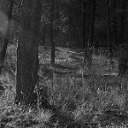

In [16]:
img_load = load(im_path*"7100.jpg")

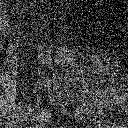

In [17]:
crrptd_img = cfunc(img_load)

Gray.(max.(0.0,min.(1.0,crrptd_img)))

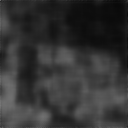

In [22]:
test_vec = zeros(Float32,128,128,1,10)
test_vec[:,:,1,1] = Float32.(crrptd_img)
y, _ = model(test_vec |> dev, ps, st)
recon_img = Gray.(min.(max.(Array(y)[:,:,1,1,1], 0.0),1.0))
recon_img

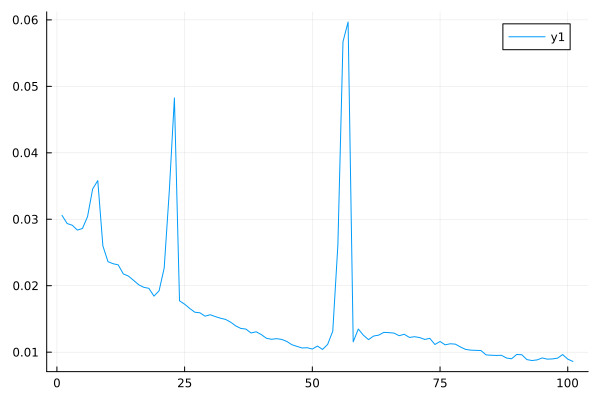

In [29]:
plot(losses[10:end])